# BÀI TẬP 5 - ANN: Đánh giá chất lượng xe ô tô
**Dataset:** UCI Car Evaluation (tải trực tiếp từ UCI)
**Labels:** unacc, acc, good, vgood

In [1]:
# ==============================================================
# BƯỚC 1: NẠP THƯ VIỆN
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==============================================================
# BƯỚC 2: ĐỌC DỮ LIỆU CAR EVALUATION (UCI)
# ==============================================================
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
col_names = ['buying','maint','doors','persons','lug_boot','safety','class']

df = pd.read_csv(url, names=col_names)
print('Shape:', df.shape)
print(df.head())
print('\nGiá trị duy nhất mỗi cột:')
for col in df.columns:
    print(f'  {col}: {df[col].unique()}')

Shape: (1728, 7)
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc

Giá trị duy nhất mỗi cột:
  buying: ['vhigh' 'high' 'med' 'low']
  maint: ['vhigh' 'high' 'med' 'low']
  doors: ['2' '3' '4' '5more']
  persons: ['2' '4' 'more']
  lug_boot: ['small' 'med' 'big']
  safety: ['low' 'med' 'high']
  class: ['unacc' 'acc' 'vgood' 'good']


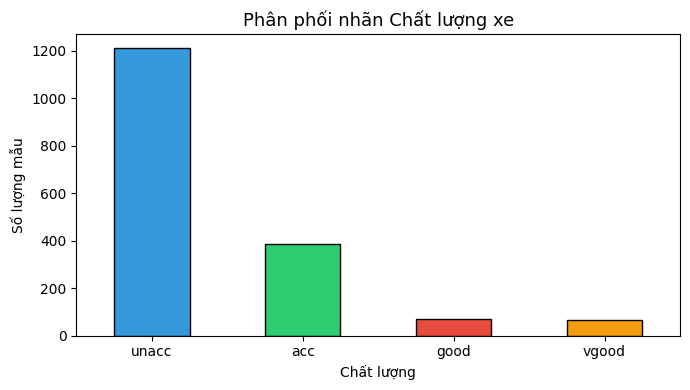

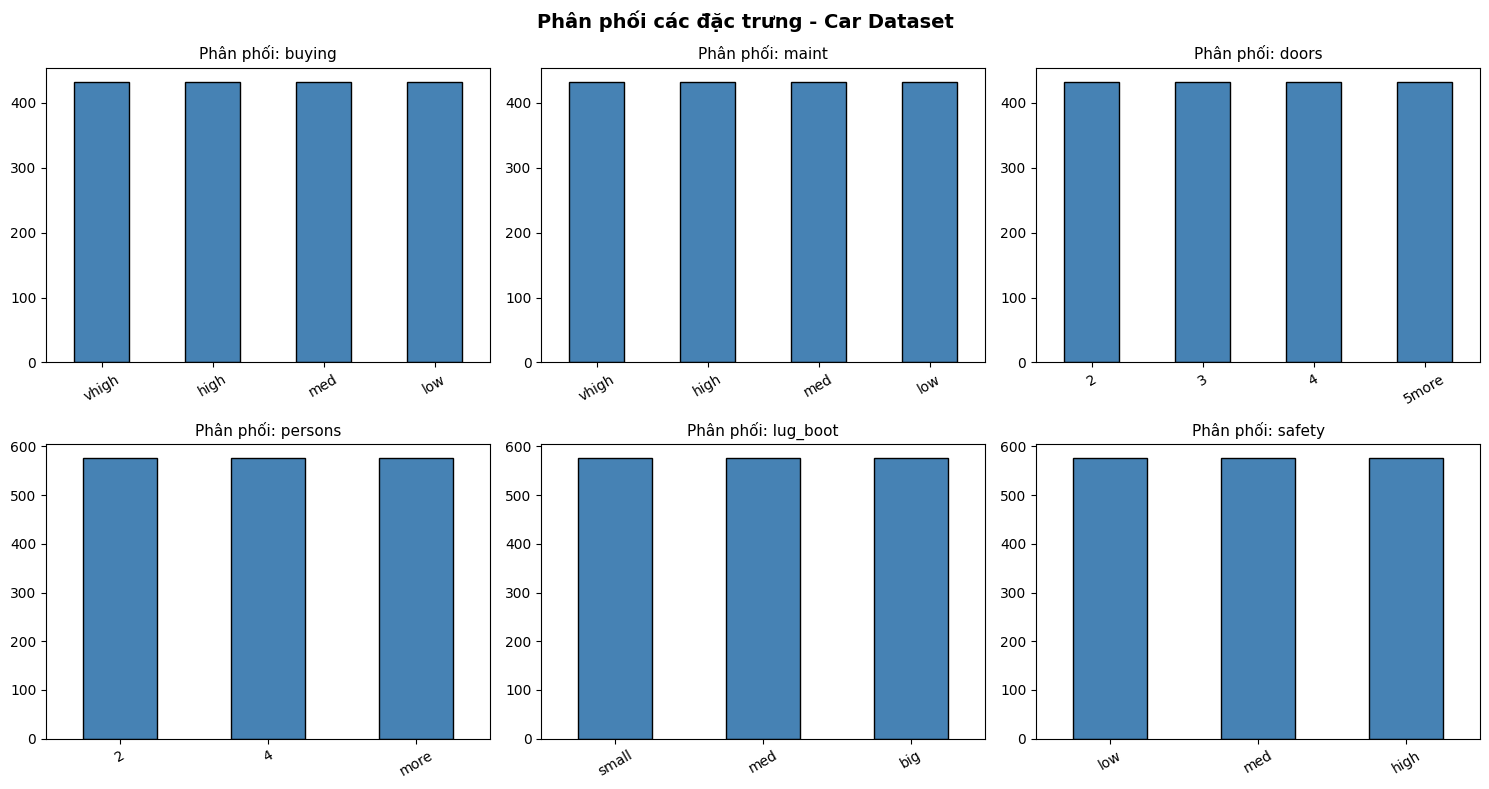

In [3]:
# ==============================================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================
# Phân phối nhãn class
plt.figure(figsize=(7, 4))
df['class'].value_counts().plot(kind='bar',
    color=['#3498DB','#2ECC71','#E74C3C','#F39C12'], edgecolor='black')
plt.title('Phân phối nhãn Chất lượng xe', fontsize=13)
plt.xlabel('Chất lượng')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Countplot các đặc trưng
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_cols = ['buying','maint','doors','persons','lug_boot','safety']
for i, col in enumerate(feature_cols):
    r, c = divmod(i, 3)
    df[col].value_counts().plot(kind='bar', ax=axes[r][c],
                                 color='steelblue', edgecolor='black')
    axes[r][c].set_title(f'Phân phối: {col}', fontsize=11)
    axes[r][c].set_xlabel('')
    axes[r][c].tick_params(axis='x', rotation=30)
plt.suptitle('Phân phối các đặc trưng - Car Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 4: XỬ LÝ DỮ LIỆU
# ==============================================================
# Encode tất cả cột categorical
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Sau encoding:')
print(df_encoded.head())
print('\nGiá trị nhãn class:', np.unique(df_encoded['class']))
print('Số classes:', len(np.unique(df_encoded['class'])))

X = df_encoded.drop('class', axis=1).values.astype('float32')
y = df_encoded['class'].values

# Feature scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Tách train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

Sau encoding:
   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2

Giá trị nhãn class: [0 1 2 3]
Số classes: 4
X_train: (1382, 6) | X_test: (346, 6)


In [5]:
# ==============================================================
# BƯỚC 5: XÂY DỰNG MÔ HÌNH ANN
# ==============================================================
num_classes = len(np.unique(y))

model = Sequential()

model.add(Dense(input_dim=X_train.shape[1], units=128,
                kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=64, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.2))

# Output: 4 classes
model.add(Dense(units=num_classes, kernel_initializer='uniform', activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,412 (36.77 KB)

 Trainable params: 9,412 (36.77 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==============================================================
# BƯỚC 6: HUẤN LUYỆN MÔ HÌNH
# ==============================================================
model_fit = model.fit(X_train, y_train,
                      validation_split=0.1,
                      epochs=50,
                      batch_size=32,
                      verbose=1)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6846 - loss: 1.1936 - val_accuracy: 0.6763 - val_loss: 0.9227
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7031 - loss: 0.8268 - val_accuracy: 0.6763 - val_loss: 0.8516
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7031 - loss: 0.7921 - val_accuracy: 0.6763 - val_loss: 0.8217
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7031 - loss: 0.7512 - val_accuracy: 0.6763 - val_loss: 0.7990
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7039 - loss: 0.7349 - val_accuracy: 0.6835 - val_loss: 0.7798
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7015 - loss: 0.7173 - val_accuracy: 0.6835 - val_loss: 0.7701
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7136 - loss: 0.7027 - val_accuracy: 0.6763 - val_loss: 0.7495
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7056 - loss: 0.6829 - val_accuracy: 0.6691 - val_loss:

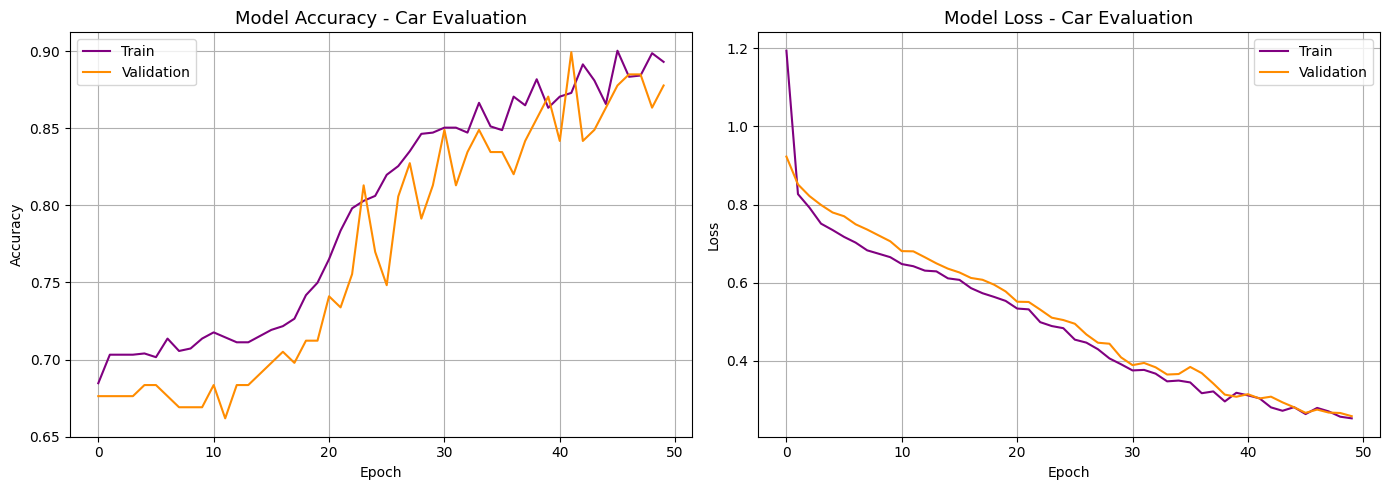

In [7]:
# ==============================================================
# BƯỚC 7: ĐÁNH GIÁ - BIỂU ĐỒ ACCURACY & LOSS
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='purple')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='darkorange')
axes[0].set_title('Model Accuracy - Car Evaluation', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='purple')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='darkorange')
axes[1].set_title('Model Loss - Car Evaluation', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

=== Classification Report ===
              precision    recall  f1-score   support

         acc       0.76      0.87      0.81        77
        good       0.00      0.00      0.00        14
       unacc       0.96      0.99      0.97       242
       vgood       1.00      0.69      0.82        13

    accuracy                           0.91       346
   macro avg       0.68      0.64      0.65       346
weighted avg       0.88      0.91      0.89       346



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


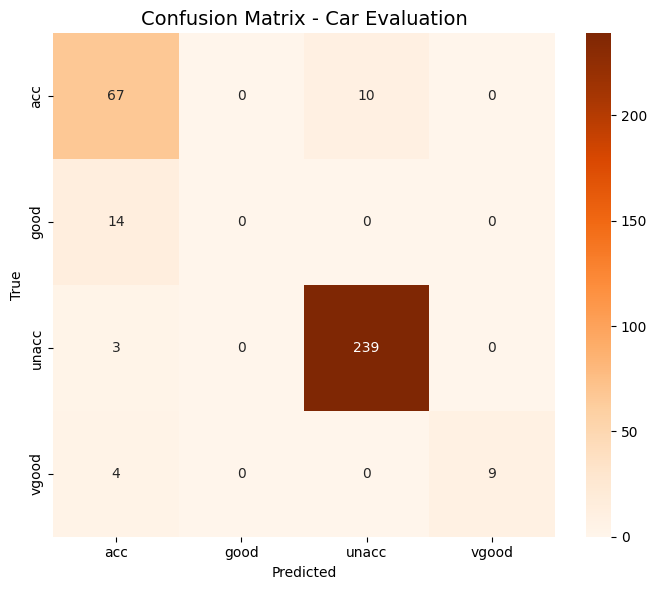


Test Accuracy: 0.9104 | Test Loss: 0.2145


In [8]:
# ==============================================================
# BƯỚC 8: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
# Giải mã nhãn
le_class = LabelEncoder()
le_class.fit(df['class'])
class_names_orig = le_class.classes_  # ['acc', 'good', 'unacc', 'vgood']

y_pred = np.argmax(model.predict(X_test), axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names_orig))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_orig, yticklabels=class_names_orig)
plt.title('Confusion Matrix - Car Evaluation', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')